In [1]:
import pandas as pd

titanic_df = pd.read_csv("titanic_data.csv")


## Basic Information

In [2]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic_df.shape

(891, 12)

In [8]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


The dataset contains **891 Titanic passenger records and 12 columns**. It includes passenger details such as age, gender, class, fare, family size, cabin, and survival status. Some values are missing in **Age, Cabin, and Embarked**. The **Survived** column is the target variable.

## Specific Information

In [10]:
# Stat info : mean Q1 median(Q2) Q3 mode std  min max corr 
titanic_df[["Age", "Fare"]].mean()

Age     29.699118
Fare    32.204208
dtype: float64

In [11]:
titanic_df[["Age", "Fare"]].median()

Age     28.0000
Fare    14.4542
dtype: float64

In [12]:
titanic_df[["Age", "Fare"]].describe()

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


In [13]:
titanic_df.Embarked.mode()

0    S
Name: Embarked, dtype: str

**Description:**
* Average age of passengers is approximately 29.7 years, indicating that most passengers were relatively young.
* Age distribution is fairly symmetric, as the mean (29.7) and median (28.0) are close.
* The minimum age is 0.42 years (about 5 months), and the oldest passenger is 80 years old.
* There are missing values in the Age column (714 entries vs. 891 for Fare), suggesting some age data is not available.
* For Fare, the mean is 32.20 and the median is 14.45 — a large gap indicating a right-skewed (positively skewed) distribution.
* Fare values range from 0 (free tickets) to over 512, showing a wide spread and presence of outliers or high-paying passengers.
* The high standard deviation (49.69) also supports the presence of large variability in fare prices.

In [28]:
# Counts
titanic_df.value_counts("Embarked", normalize=False, dropna=True)

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Interestingly, large group of passangers embarked from Southampton.

In [34]:
titanic_df.value_counts(["Sex","Survived"])

Sex     Survived
male    0           468
female  1           233
male    1           109
female  0            81
Name: count, dtype: int64

In [33]:
titanic_df[titanic_df.Sex == "female"].value_counts("Survived")

Survived
1    233
0     81
Name: count, dtype: int64

In [38]:
# Embarked from S , Fare Distribution ?
titanic_df[ titanic_df.Embarked == "S" ]["Fare"].describe()

count    644.000000
mean      27.079812
std       35.887993
min        0.000000
25%        8.050000
50%       13.000000
75%       27.900000
max      263.000000
Name: Fare, dtype: float64

In [43]:
# Embarked from S and gender Male , Survival rate ?
titanic_df[
    (titanic_df.Embarked == "S") & (titanic_df["Sex"] == "male")
].value_counts("Survived")

Survived
0    364
1     77
Name: count, dtype: int64

In [18]:
#Pandas Crosstab

pd.crosstab(
    index = titanic_df.Sex,
    columns= titanic_df.Survived,
    margins= True,
    margins_name= "Total",
    colnames=["Rate of Survival"],
    rownames=["Gender"],
    
    # aggfunc = "mean",
    # values=titanic_df.Fare
)

Rate of Survival,0,1,Total
Gender,,,
female,81,233,314
male,468,109,577
Total,549,342,891


In [19]:
pd.crosstab(
    titanic_df.Sex,
    [titanic_df.Survived, titanic_df.Pclass],
    margins = False,
)

Survived   0            1        
Pclass     1   2    3   1   2   3
Sex                              
female     3   6   72  91  70  72
male      77  91  300  45  17  47

In [20]:
# Get unique Values
titanic_df.Embarked.unique()

<ArrowStringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [22]:
titanic_df.Embarked.nunique(dropna = False)

4

In [26]:
# sum() , prod(), cumsum(), var(), std(),  mean(), quantile()
titanic_df.Age.quantile(q = 0.75)

np.float64(38.0)

In [27]:
titanic_df.Age.var()

np.float64(211.01912474630802)

In [31]:
titanic_df.Embarked.mode()

0    S
Name: Embarked, dtype: str

### 0 -> column wise -> vertical
### 1 -> row wise -> horizontal

In [35]:
titanic_df.isna().sum(axis = 0)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [42]:
# GroupBy

sample_df = titanic_df[["Sex","Fare","Age","Survived", "Embarked"]]
sample_df.head()

,Sex,Fare,Age,Survived,Embarked
0,male,7.2500,22.0,0,S
1,female,71.2833,38.0,1,C
2,female,7.9250,26.0,1,S
3,female,53.1000,35.0,1,S
4,male,8.0500,35.0,0,S


In [45]:
group_by_gender = sample_df.groupby(by="Sex")
group_by_gender

In [47]:
group_by_gender.mean(numeric_only=True)

,Fare,Age,Survived
Sex,,,
female,44.479818,27.915709,0.742038
male,25.523893,30.726645,0.188908


In [49]:
group_by_gender.value_counts(["Survived"])

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

In [50]:
group_by_two = titanic_df.groupby(by = ["Embarked", "Survived"])

In [53]:
group_by_two.count()

PassengerId  Pclass  Name  Sex  Age  SibSp  Parch  Ticket  \
Embarked Survived                                                              
C        0                  75      75    75   75   51     75     75      75   
         1                  93      93    93   93   79     93     93      93   
Q        0                  47      47    47   47   20     47     47      47   
         1                  30      30    30   30    8     30     30      30   
S        0                 427     427   427  427  353    427    427     427   
         1                 217     217   217  217  201    217    217     217   

                   Fare  Cabin  
Embarked Survived               
C        0           75     17  
         1           93     52  
Q        0           47      2  
         1           30      2  
S        0          427     49  
         1          217     80

### Correlation and Covariance

In [58]:
titanic_df[["Age", "Fare"]].cov()

,Age,Fare
Age,211.019125,73.849030
Fare,73.849030,2469.436846


In [59]:
titanic_df[["Age", "Fare"]].corr()

,Age,Fare
Age,1.000000,0.096067
Fare,0.096067,1.000000


0.096 -> no correlation

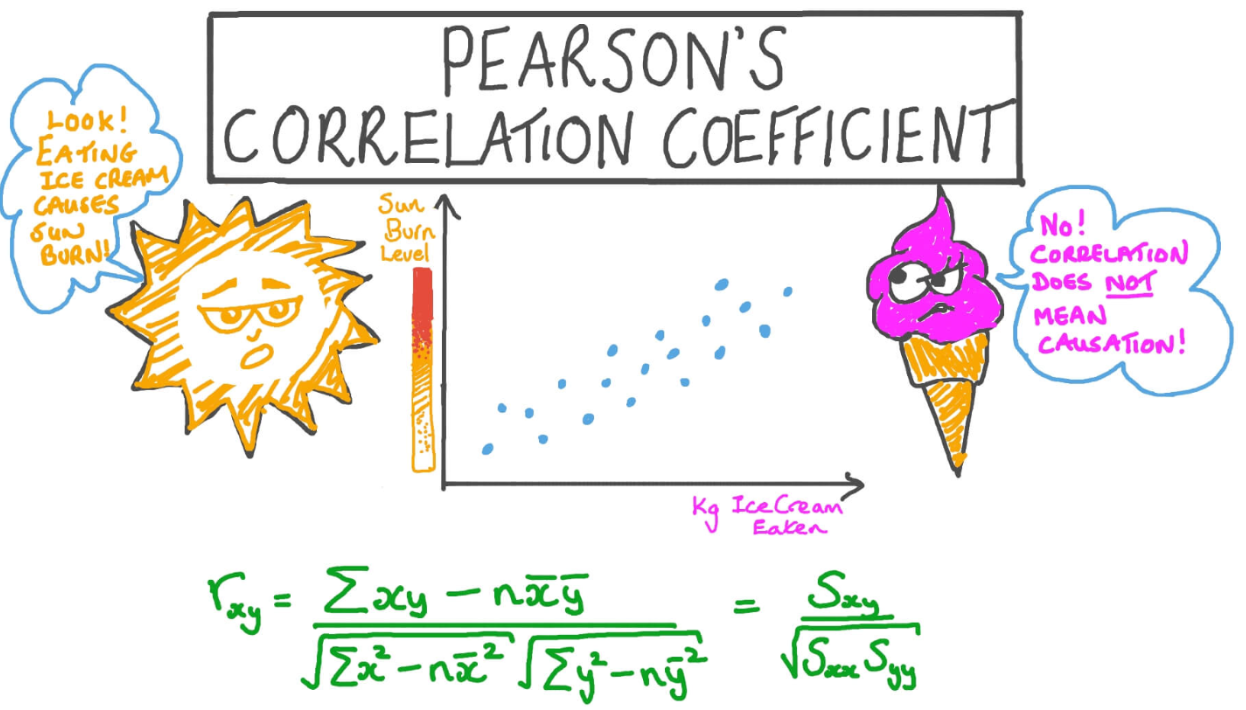

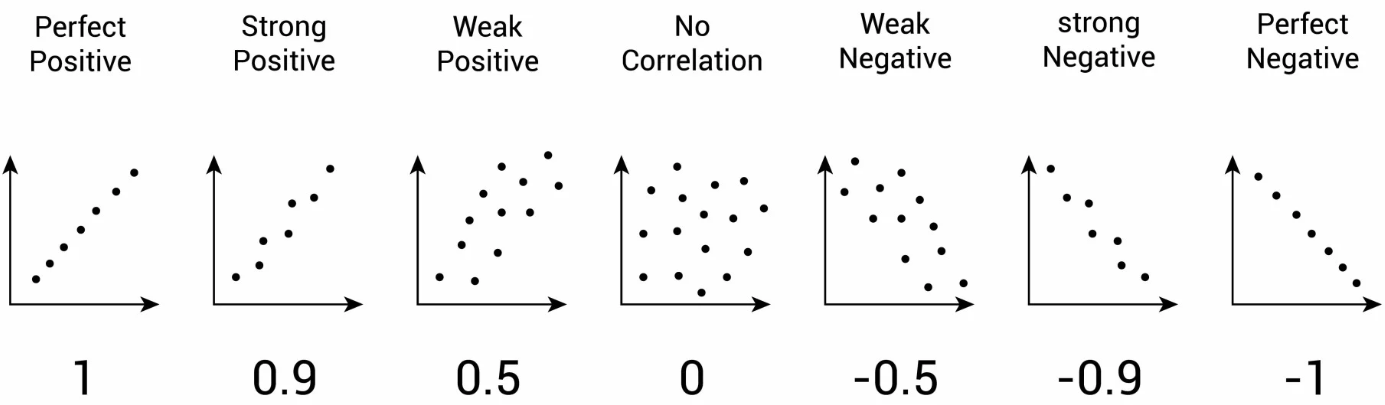

In [61]:
titanic_df[["Age", "Fare"]].corr()

,Age,Fare
Age,1.000000,0.096067
Fare,0.096067,1.000000


In [63]:
titanic_df["Age"].corr(titanic_df["Fare"]) 

np.float64(0.0960666917690389)

In [64]:
# sample
sampled_df = titanic_df.sample(n = 300, random_state=999)

In [67]:
sampled_df.mean(numeric_only=True)

PassengerId    451.633333
Survived         0.366667
Pclass           2.353333
Age             29.880250
SibSp            0.530000
Parch            0.380000
Fare            31.413222
dtype: float64

In [68]:
sampled_df[["Age", "Fare"]].corr()

,Age,Fare
Age,1.00000,0.03441
Fare,0.03441,1.00000
